In [3]:
# 1. 导入库
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# 2. 读取数据，这里的前五行数据刚好是NaN
stocks = pd.read_csv(r"D:\data\sp500_stocks.csv")
stocks.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#3.这里用dropna()来验证一下清除空值后的前五行数据是否是NaN
stocks.dropna().head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
3768,2010-01-04,AOS,5.937266,7.435000,7.480000,7.261667,7.295000,1104600.0
3769,2010-01-05,AOS,5.861404,7.340000,7.431667,7.308333,7.431667,1207200.0
3770,2010-01-06,AOS,5.864068,7.343333,7.405000,7.301667,7.335000,663000.0
3771,2010-01-07,AOS,5.881369,7.365000,7.425000,7.311667,7.356667,564000.0
3772,2010-01-08,AOS,5.967879,7.473333,7.485000,7.311667,7.331667,504600.0


In [8]:
#4.第一行：看看过滤空值后的数据长啥样（前 5 行）
#第二行：看看哪些股票的数据最多（前 20 名）
stocks[stocks["Close"].notna()].head()
stocks[stocks["Close"].notna()]["Symbol"].value_counts().head(20)

Symbol
AOS     3768
HSIC    3768
MSFT    3768
MSI     3768
NDAQ    3768
NTAP    3768
NFLX    3768
NVDA    3768
OMC     3768
ON      3768
ORCL    3768
PKG     3768
PARA    3768
PH      3768
PAYX    3768
PEP     3768
PM      3768
PNW     3768
PNC     3768
MTD     3768
Name: count, dtype: int64

In [10]:
#5.筛选NVDA不输出
nvda = stocks[stocks["Symbol"] == "NVDA"].copy()

In [13]:
# 6.清洗数据
nvda = nvda.dropna()
nvda["Date"] = pd.to_datetime(nvda["Date"])
nvda.head()
nvda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3768 entries, 1307496 to 1311263
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       3768 non-null   datetime64[ns]
 1   Symbol     3768 non-null   object        
 2   Adj Close  3768 non-null   float64       
 3   Close      3768 non-null   float64       
 4   High       3768 non-null   float64       
 5   Low        3768 non-null   float64       
 6   Open       3768 non-null   float64       
 7   Volume     3768 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 264.9+ KB


In [17]:
# 7. 计算收益率
nvda["Return"] = nvda["Close"].pct_change()
nvda["Return"].describe()

count    3767.000000
mean        0.001914
std         0.028637
min        -0.187559
25%        -0.012497
50%         0.001659
75%         0.015892
max         0.298067
Name: Return, dtype: float64

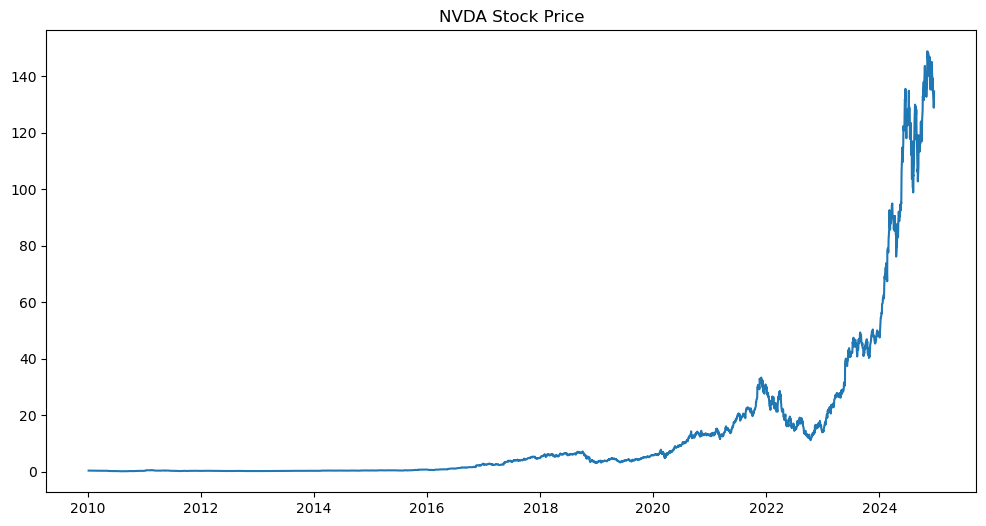

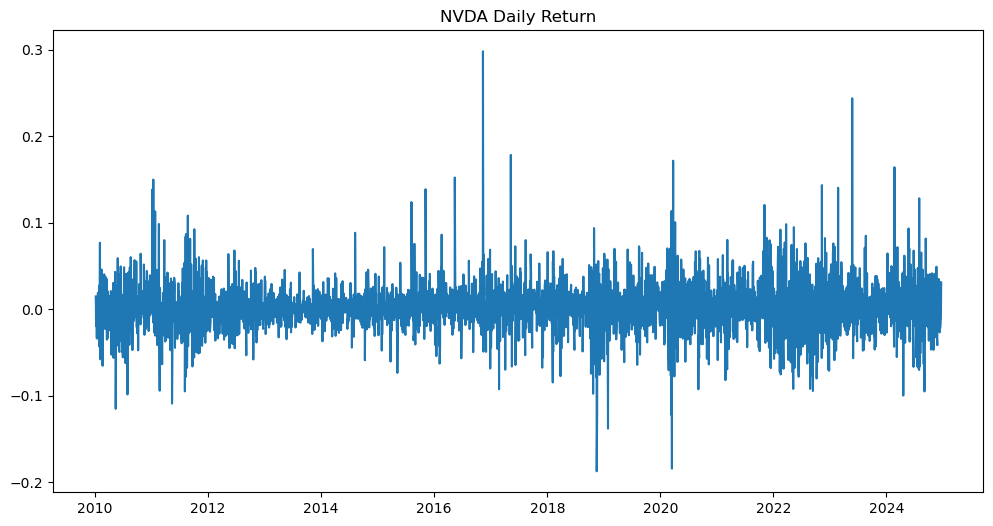

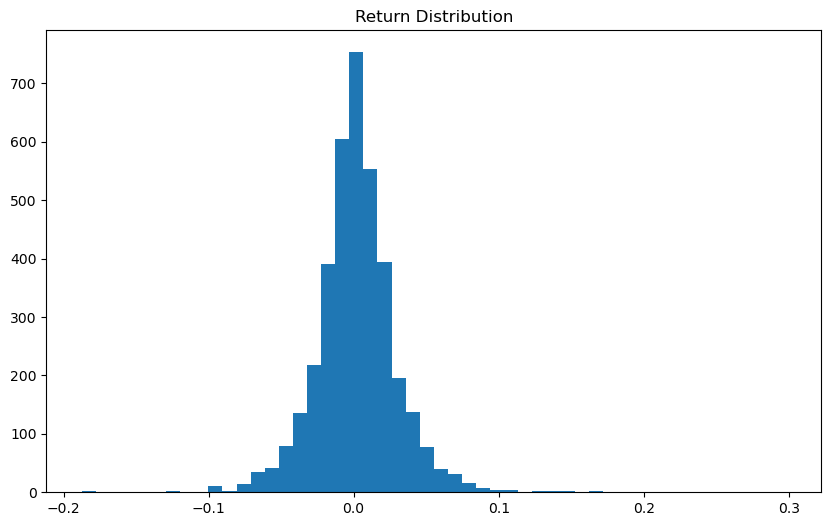

In [23]:
# 8. 可视化，股票价格走势图，日收益率，收益率分布图
plt.figure(figsize=(12,6))
plt.plot(nvda["Date"], nvda["Close"])
plt.title("NVDA Stock Price")
plt.savefig("price.png")   
plt.show()

plt.figure(figsize=(12,6))
plt.plot(nvda["Date"], nvda["Return"])
plt.title("NVDA Daily Return")
plt.savefig("return.png")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(nvda["Return"].dropna(), bins=50)
plt.title("Return Distribution")
plt.savefig("distribution.png")
plt.show()

In [19]:
'''9.总结，从下面的描述和以上图像可得出结论英伟达在研究期间内整体呈现出显著的长期增长趋势
日收益率波动较大，短期价格变化较为频繁
收益率分布以小幅涨跌为主，但存在少量极端波动
股价增长主要集中在近几年，尤其是 AI 行业快速发展的阶段'''
nvda.describe()

,Date,Adj Close,Close,High,Low,Open,Volume,Return
count,3768,3768.000000,3768.000000,3768.000000,3768.000000,3768.000000,3.768000e+03,3767.000000
mean,2017-06-27 13:11:27.898089216,13.781238,13.810257,14.061996,13.536992,13.812272,4.975500e+08,0.001914
min,2010-01-04 00:00:00,0.203593,0.222000,0.226250,0.216250,0.218000,4.564400e+07,-0.187559
25%,2013-09-30 18:00:00,0.410619,0.442437,0.449500,0.435688,0.443438,3.038620e+08,-0.012497
50%,2017-06-27 12:00:00,3.521607,3.555250,3.624000,3.445625,3.535750,4.285000e+08,0.001659
75%,2021-03-25 06:00:00,13.522803,13.547563,13.827750,13.339563,13.590937,6.028640e+08,0.015892
max,2024-12-20 00:00:00,148.869751,148.880005,152.889999,146.259995,149.350006,3.692928e+09,0.298067
std,NaN,27.672499,27.669146,28.188744,27.119226,27.700228,3.064019e+08,0.028637
